In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Data Loading

In [2]:
df = pd.read_csv('hourly_windspeed.csv')
df.head()

,YEAR,MO,DY,HR,T2M,PS,WS50M,WD50M,RH2M
0,2014,1,1,0,4.38,98.01,9.33,183.0,97.00
1,2014,1,1,1,4.38,97.97,8.69,184.2,97.34
2,2014,1,1,2,4.26,97.94,8.02,182.4,97.57
3,2014,1,1,3,4.12,97.91,7.94,183.6,97.92
4,2014,1,1,4,3.93,97.88,7.56,174.2,98.25


## 2. Exploratory Analysis

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96432 entries, 0 to 96431
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   YEAR    96432 non-null  int64  
 1   MO      96432 non-null  int64  
 2   DY      96432 non-null  int64  
 3   HR      96432 non-null  int64  
 4   T2M     96432 non-null  float64
 5   PS      96432 non-null  float64
 6   WS50M   96432 non-null  float64
 7   WD50M   96432 non-null  float64
 8   RH2M    96432 non-null  float64
dtypes: float64(5), int64(4)
memory usage: 6.6 MB


In [4]:
df.describe()

,YEAR,MO,DY,HR,T2M,PS,WS50M,WD50M,RH2M
count,96432.000000,96432.000000,96432.000000,96432.000000,96432.000000,96432.000000,96432.000000,96432.000000,96432.000000
mean,2019.000747,6.522648,15.730463,11.500000,9.507215,99.806190,7.190018,204.645745,88.228043
std,3.162491,3.448798,8.800486,6.922222,5.464625,1.187308,3.311282,87.450750,11.462889
min,2014.000000,1.000000,1.000000,0.000000,-5.780000,94.700000,0.020000,0.000000,37.230000
25%,2016.000000,4.000000,8.000000,5.750000,5.420000,99.110000,4.900000,142.800000,82.540000
50%,2019.000000,7.000000,16.000000,11.500000,9.260000,99.940000,6.910000,219.600000,92.790000
75%,2022.000000,10.000000,23.000000,17.250000,13.450000,100.620000,9.010000,273.600000,96.600000
max,2024.000000,12.000000,31.000000,23.000000,30.400000,103.140000,25.370000,359.900000,100.000000


In [5]:
df = df.rename(columns={'YEAR':'year', 'MO':'month', 'DY':'day', 'HR':'hour'})
df['datetime'] = pd.to_datetime(df[['year','month','day','hour']])

In [6]:
df = df.set_index('datetime')
df.head()

,year,month,day,hour,T2M,PS,WS50M,WD50M,RH2M
datetime,,,,,,,,,
2014-01-01 00:00:00,2014,1,1,0,4.38,98.01,9.33,183.0,97.00
2014-01-01 01:00:00,2014,1,1,1,4.38,97.97,8.69,184.2,97.34
2014-01-01 02:00:00,2014,1,1,2,4.26,97.94,8.02,182.4,97.57
2014-01-01 03:00:00,2014,1,1,3,4.12,97.91,7.94,183.6,97.92
2014-01-01 04:00:00,2014,1,1,4,3.93,97.88,7.56,174.2,98.25


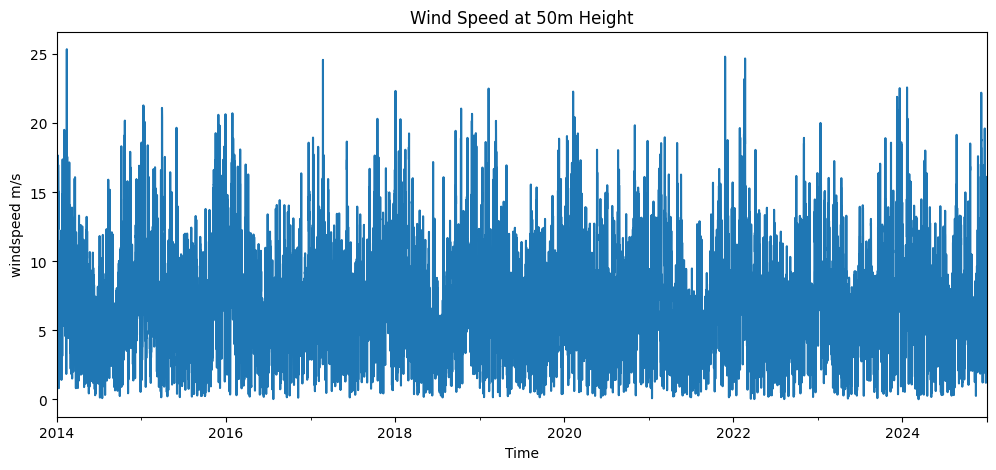

In [7]:
df['WS50M'].plot(figsize=(12,5))
plt.title('Wind Speed at 50m Height')
plt.ylabel('windspeed m/s')
plt.xlabel('Time')
plt.show()

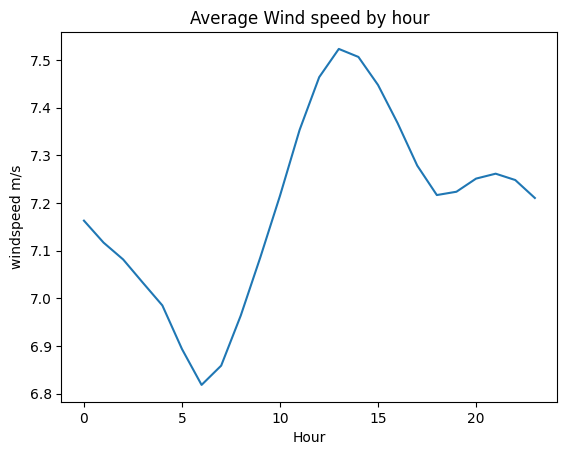

In [8]:
df.groupby('hour')['WS50M'].mean().plot()
plt.title('Average Wind speed by hour')
plt.ylabel('windspeed m/s')
plt.xlabel('Hour')
plt.show()

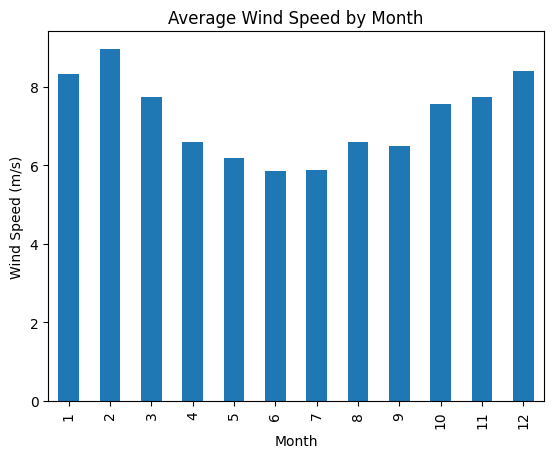

In [9]:
df.groupby('month')['WS50M'].mean().plot(kind='bar')
plt.title("Average Wind Speed by Month")
plt.ylabel("Wind Speed (m/s)")
plt.xlabel("Month")
plt.show()

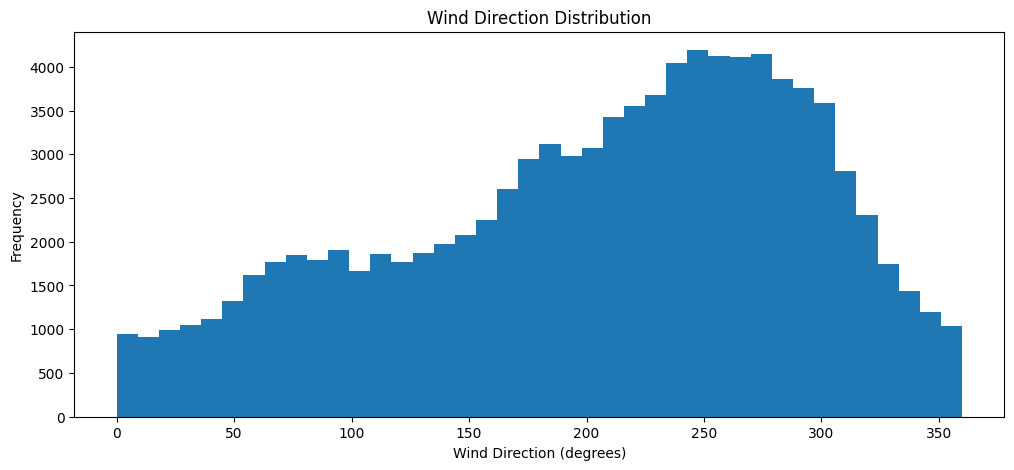

In [10]:
df['WD50M'].plot(kind='hist', bins=40, figsize=(12,5))
plt.title('Wind Direction Distribution')
plt.xlabel('Wind Direction (degrees)')
plt.ylabel('Frequency')
plt.show()

In [11]:
cols = ['WS50M', 'WD50M', 'T2M','PS','RH2M']
df[cols].corr()

,WS50M,WD50M,T2M,PS,RH2M
WS50M,1.000000,0.106287,-0.116116,-0.393039,0.066404
WD50M,0.106287,1.000000,0.044819,-0.043861,-0.034269
T2M,-0.116116,0.044819,1.000000,0.068855,-0.579720
PS,-0.393039,-0.043861,0.068855,1.000000,-0.118199
RH2M,0.066404,-0.034269,-0.579720,-0.118199,1.000000


### Plot Wind Speed Histgoram

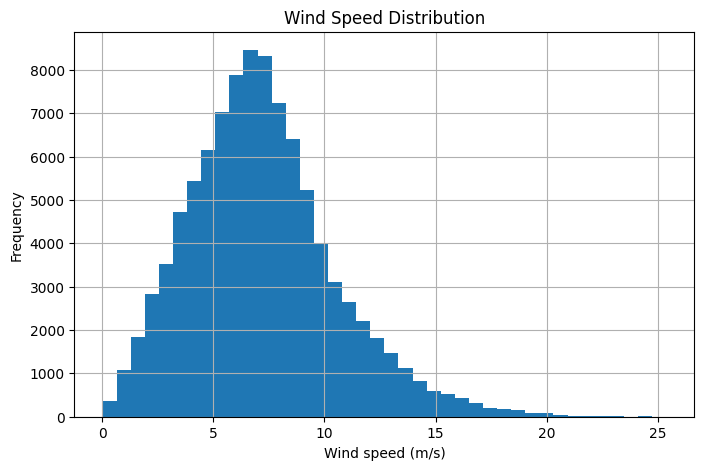

In [12]:
plt.figure(figsize=(8,5))
df['WS50M'].hist(bins=40)

plt.xlabel("Wind speed (m/s)")
plt.ylabel("Frequency")
plt.title("Wind Speed Distribution")

plt.show()

## 3. Weibull Wind Speed Distribution

In [13]:
from scipy.stats import weibull_min

wind = df['WS50M'].dropna()

shape, loc, scale = weibull_min.fit(wind, floc=0)
k = shape
c = scale
print("Shape k:", k)
print("Scale c:", c)

Shape k: 2.285287765115721
Scale c: 8.11161362460724


### Plot Weibull Fit
Check:
If the curve follows the histogram well

If yes > Weibull model is good

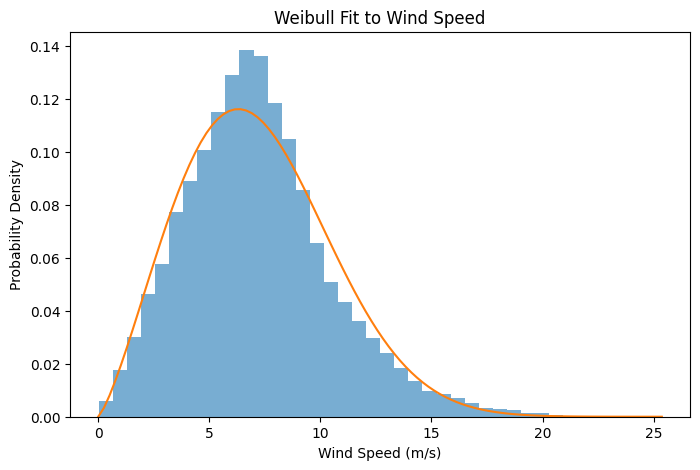

In [14]:
x = np.linspace(0, wind.max(), 100)
pdf = weibull_min.pdf(x, k, loc=0, scale = c)
plt.figure(figsize=(8,5))
plt.hist(wind, bins=40, density=True, alpha=0.6)
plt.plot(x, pdf)
plt.title("Weibull Fit to Wind Speed")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Probability Density")
plt.show()

## 4. Wind Resource Assessment

### Mean Wind Speed

In [15]:
mean_ws = df['WS50M'].mean()
print("Mean Wind Speed at 50m:", mean_ws)

Mean Wind Speed at 50m: 7.190018251202921


### Wind Power Density

Estimate energy potential

Formula:

P=1/2​ρv3

ρ = air denstiy(~1.225)

In [16]:
rho = 1.225
power_density = 0.5 * rho * (wind**3)

print("Mean Wind Power Density:", power_density.mean(), "W/m^2")

Mean Wind Power Density: 388.0231123934579 W/m^2


### Wind Power Classes

In [17]:
data = {
    "Hour": [1, 2, 3],
    "Wind Speed (m/s)": [5.4, 6.2, 7.1],
    "Temperature (°C)": [12, 13, 14]
}

In [18]:
windpowerdensityclass = {
    "Class(W/m^2)": ['<200', '200-300', '300-400', '400-600', '>600'],
    "Power Density":['Poor', 'Marginal', 'Moderate', 'Good', 'Excellent']
}
windpowerclass = pd.DataFrame(windpowerdensityclass)
print(windpowerclass.to_markdown(index=False))

| Class(W/m^2)   | Power Density   |
|:---------------|:----------------|
| <200           | Poor            |
| 200-300        | Marginal        |
| 300-400        | Moderate        |
| 400-600        | Good            |
| >600           | Excellent       |


## 5. Wind Rose Analysis

In [19]:
from windrose import WindroseAxes

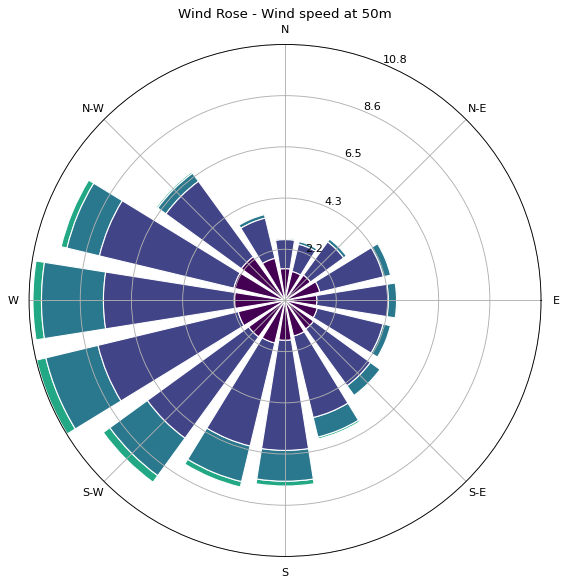

In [20]:
ws = df['WS50M']
wd = df['WD50M']

ax = WindroseAxes.from_ax()

ax.bar(wd, ws, normed=True, opening=0.8, edgecolor='white')
ax.set_title('Wind Rose - Wind speed at 50m')
plt.show()

## 6. Autocorrelation Analysis

### Autocorrelation Plot

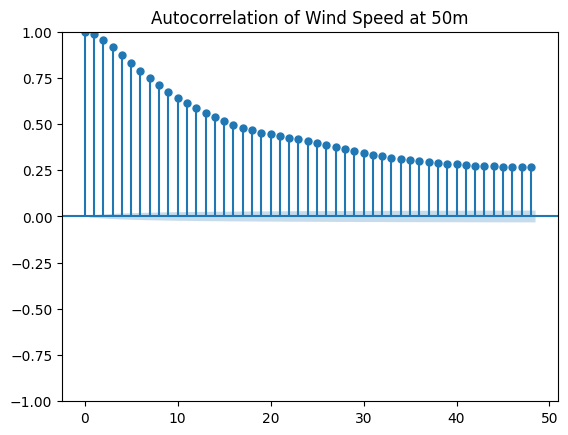

In [21]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df['WS50M'], lags=48)
plt.title("Autocorrelation of Wind Speed at 50m")
plt.show()

### Partial Autocorrelation

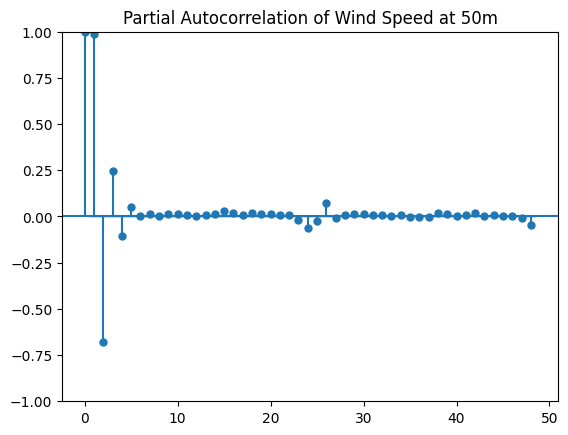

In [22]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(df['WS50M'], lags=48)
plt.title("Partial Autocorrelation of Wind Speed at 50m")
plt.show()

## 7. Wind Speed Duration Curve (WSDC)

### Sorting Wind Speeds

In [23]:
sorted_ws = np.sort(wind)[::-1]

### Calculating Time Percentage

In [24]:
time_percent = np.arange(1, len(sorted_ws)+1) / len(sorted_ws) * 100

### Plotting Wind Speed Duration Curve

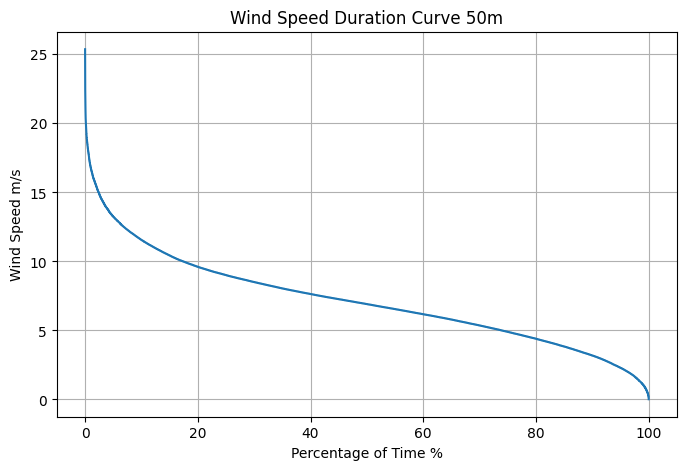

In [26]:
plt.figure(figsize=(8,5))
plt.plot(time_percent, sorted_ws)
plt.xlabel("Percentage of Time %")
plt.ylabel("Wind Speed m/s")
plt.title("Wind Speed Duration Curve 50m")
plt.grid(True)
plt.show()

## Estimating Annual Energy Production (AEP)

### Calculating Turbine Power

In [27]:
def turbine_power(v):
    if v < 3:
        return 0
    elif v <12:
        return 2000 * ((v-3)/9)**3
    elif v <= 25:
        return 2000
    else:
        return 0

In [28]:
df['power_kw'] = df['WS50M'].apply(turbine_power)

### Energy Production each hour

In [29]:
df['energy_kwh'] = df['power_kw']

### Total Energy over 10 years

In [30]:
total_energy_kwh = df['energy_kwh'].sum()
print("Total energy over 10 years (kWh):", total_energy_kwh,'kWh')

Total energy over 10 years (kWh): 43667730.14162963 kWh


In [31]:
hours = len(df)
years = hours / 8760
print("Total years of data:", years)

Total years of data: 11.008219178082191


### Computing Average Annual Energy Prodcution

In [32]:
AEP_kWh = total_energy_kwh / years
AEP_MWh = AEP_kWh / 1000
print("Annual Energy Production (MWh):", AEP_MWh, 'MWh')

Annual Energy Production (MWh): 3966.829642034548 MWh


### Calcuating Capacity Factor
Rated power * hours per year

In [35]:
rated_power = 2000 #kW
max_energy_year = rated_power * 8760
capacity_factor = AEP_kWh / max_energy_year *100
print("Capacity Factor:", capacity_factor,'%')

Capacity Factor: 22.641721701110434 %
